## 01 - Data Exploration and Preprocessing

This notebook performs an initial exploration of the job-posting dataset
to understand its structure, quality, characteristics, and suitability
for job-market skill demand analysis and career recommendation.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [49]:
df = pd.read_csv("data/job_postings.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [50]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 15000
Number of columns: 16


In [51]:
df.columns

Index(['job_id', 'title', 'company', 'location', 'remote_type', 'industry',
       'company_size', 'experience_level', 'salary_min', 'salary_max',
       'required_skills', 'education_required', 'description', 'posted_date',
       'applications', 'days_to_fill'],
      dtype='object')

In [52]:
df.head()

,job_id,title,company,location,remote_type,industry,company_size,experience_level,salary_min,salary_max,required_skills,education_required,description,posted_date,applications,days_to_fill
0,JOB13473,Data Scientist,PolicyData Corp,"Pittsburgh, PA",onsite,government,startup,senior,138000,164000,Jupyter|Deep Learning|Python|Statistics|NLP|SQL|A/B Testing,bachelor,Join PolicyData Corp as a senior Data Scientist and help us build product analytics infrastructu...,2023-01-01,26,61
1,JOB10866,Data Engineer,LearnEdge Systems,"Omaha, NE",remote,education,medium,mid,85000,103000,Python|PostgreSQL|BigQuery|Spark,bachelor,"LearnEdge Systems is looking for a passionate Data Engineer with expertise in Python, PostgreSQL...",2023-01-01,75,55
2,JOB12905,Product Manager,Keystone Public Analytics,"Albuquerque, NM",hybrid,government,startup,entry,63000,77000,User Research|JIRA,bachelor,Join Keystone Public Analytics as a entry Product Manager and help us build enterprise data plat...,2023-01-01,22,34
3,JOB01986,Research Scientist,Quantum Leap Digital,"Albuquerque, NM",onsite,tech,startup,entry,61000,71000,PyTorch|Statistics,bachelor,Quantum Leap Digital is looking for a passionate Research Scientist with expertise in PyTorch an...,2023-01-01,18,37
4,JOB07952,Backend Engineer,Fabricate AI,"Albuquerque, NM",onsite,manufacturing,large,director,208000,245000,Python|PostgreSQL|Redis|Java|Docker|REST APIs|Go|gRPC|SQL,master,"As a director Backend Engineer at Fabricate AI, you will leverage Python, PostgreSQL, and Redis ...",2023-01-01,131,114


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_id              15000 non-null  object
 1   title               15000 non-null  object
 2   company             15000 non-null  object
 3   location            15000 non-null  object
 4   remote_type         15000 non-null  object
 5   industry            15000 non-null  object
 6   company_size        15000 non-null  object
 7   experience_level    15000 non-null  object
 8   salary_min          15000 non-null  int64 
 9   salary_max          15000 non-null  int64 
 10  required_skills     15000 non-null  object
 11  education_required  15000 non-null  object
 12  description         15000 non-null  object
 13  posted_date         15000 non-null  object
 14  applications        15000 non-null  int64 
 15  days_to_fill        15000 non-null  int64 
dtypes: int64(4), object(12

In [54]:
missing_values = df.isnull().sum()

print(missing_values)

job_id                0
title                 0
company               0
location              0
remote_type           0
industry              0
company_size          0
experience_level      0
salary_min            0
salary_max            0
required_skills       0
education_required    0
description           0
posted_date           0
applications          0
days_to_fill          0
dtype: int64


In [55]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [56]:
print("Duplicate Job IDs:", df['job_id'].duplicated().sum())

Duplicate Job IDs: 0


In [57]:
df.describe()

,salary_min,salary_max,applications,days_to_fill
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,146675.333333,183369.933333,101.238267,56.067067
std,62131.326063,78274.867484,64.810472,31.156191
min,42000.000000,49000.000000,10.000000,15.000000
25%,99000.000000,124000.000000,45.000000,34.000000
50%,136000.000000,170000.000000,83.000000,48.000000
75%,182000.000000,228000.000000,143.000000,72.000000
max,466000.000000,576000.000000,276.000000,180.000000


In [58]:
df[['salary_min', 'salary_max', 'applications', 'days_to_fill']].describe()

,salary_min,salary_max,applications,days_to_fill
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,146675.333333,183369.933333,101.238267,56.067067
std,62131.326063,78274.867484,64.810472,31.156191
min,42000.000000,49000.000000,10.000000,15.000000
25%,99000.000000,124000.000000,45.000000,34.000000
50%,136000.000000,170000.000000,83.000000,48.000000
75%,182000.000000,228000.000000,143.000000,72.000000
max,466000.000000,576000.000000,276.000000,180.000000


In [59]:
print("Unique job titles:", df['title'].nunique())

df['title'].value_counts().head(20)

Unique job titles: 10


title
Software Engineer     1552
UX Designer           1550
Product Manager       1520
Data Analyst          1520
ML Engineer           1514
Data Engineer         1496
Data Scientist        1484
Backend Engineer      1463
DevOps Engineer       1452
Research Scientist    1449
Name: count, dtype: int64

In [60]:
print("Unique industries:", df['industry'].nunique())

df['industry'].value_counts()

Unique industries: 8


industry
finance          1924
education        1913
government       1894
media            1873
manufacturing    1867
retail           1857
tech             1842
healthcare       1830
Name: count, dtype: int64

In [61]:
df['experience_level'].value_counts()

experience_level
mid         4378
senior      4258
entry       3037
lead        2096
director    1231
Name: count, dtype: int64

In [62]:
df['education_required'].value_counts()

education_required
bachelor    7591
master      4747
phd         1952
none         710
Name: count, dtype: int64

In [63]:
df['remote_type'].value_counts()

remote_type
hybrid    6002
onsite    4506
remote    4492
Name: count, dtype: int64

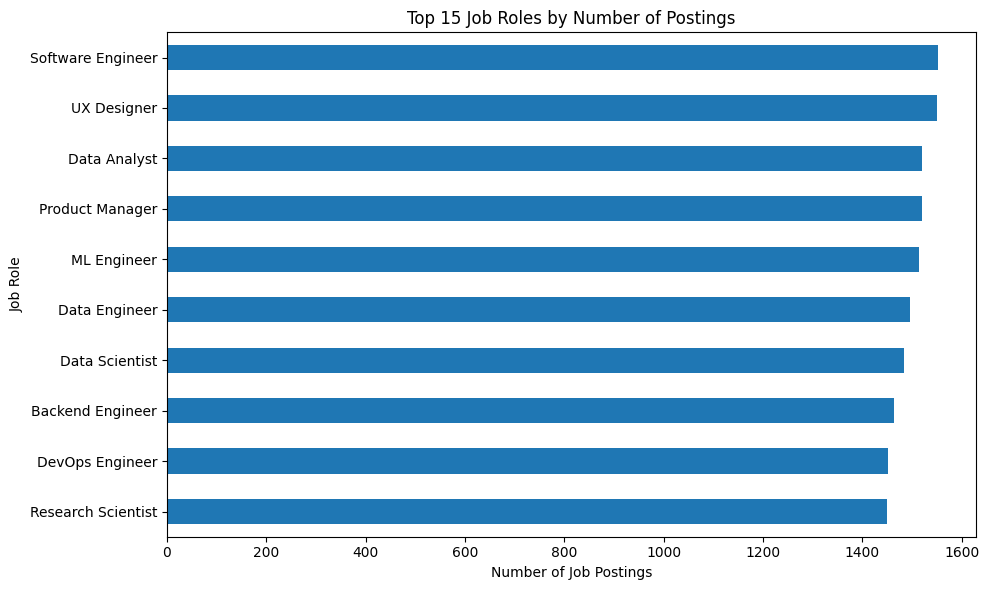

In [64]:
top_jobs = df['title'].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_jobs.sort_values().plot(kind='barh')

plt.title('Top 15 Job Roles by Number of Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

In [65]:
skills_series = df['required_skills'].dropna().str.split('|').explode()

skills_series = skills_series.str.strip()

print("Total skill records:", len(skills_series))
print("Unique skills:", skills_series.nunique())

Total skill records: 87368
Unique skills: 69


In [66]:
top_skills = skills_series.value_counts().head(20)

top_skills

required_skills
Python              5873
SQL                 4363
Docker              2675
Kubernetes          2673
AWS                 2672
Statistics          2454
A/B Testing         2432
TensorFlow          2330
PyTorch             2304
Spark               2064
PostgreSQL          1911
User Research       1893
Figma               1869
Machine Learning    1574
Deep Learning       1550
dbt                 1547
Tableau             1482
Airflow             1403
CI/CD               1394
Kafka               1388
Name: count, dtype: int64

In [67]:
df['posted_date'] = pd.to_datetime(df['posted_date'])

print(df['posted_date'].min())
print(df['posted_date'].max())

2023-01-01 00:00:00
2025-12-30 00:00:00


In [68]:
print(df['posted_date'].dt.year.value_counts())

posted_date
2024    5089
2023    4968
2025    4943
Name: count, dtype: int64


In [69]:
df['skill_count'] = df['required_skills'].str.split('|').str.len()

df['skill_count'].describe()

count    15000.000000
mean         5.824533
std          1.997234
min          2.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: skill_count, dtype: float64

In [70]:
print("Average skills per job:",
      round(df['skill_count'].mean(), 2))

print("Minimum skills per job:",
      df['skill_count'].min())

print("Maximum skills per job:",
      df['skill_count'].max())

Average skills per job: 5.82
Minimum skills per job: 2
Maximum skills per job: 10


In [71]:
data_scientist_jobs = df[df['title'] == 'Data Scientist']

ds_skills = (
    data_scientist_jobs['required_skills']
    .str.split('|')
    .explode()
    .str.strip()
    .value_counts()
)

ds_skills.head(15)

required_skills
scikit-learn        657
NLP                 649
SQL                 645
A/B Testing         642
Machine Learning    638
R                   636
Spark               632
Statistics          625
TensorFlow          624
Deep Learning       617
Python              605
PyTorch             604
Tableau             592
Jupyter             576
Name: count, dtype: int64

In [72]:
data_analyst_jobs = df[df['title'] == 'Data Analyst']

da_skills = (
    data_analyst_jobs['required_skills']
    .str.split('|')
    .explode()
    .str.strip()
    .value_counts()
)

da_skills.head(15)

required_skills
A/B Testing         897
Statistics          894
Tableau             890
Excel               887
dbt                 884
Power BI            883
Google Analytics    880
Looker              880
Python              877
SQL                 876
Name: count, dtype: int64

In [73]:
df['skill_count'].describe()

count    15000.000000
mean         5.824533
std          1.997234
min          2.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: skill_count, dtype: float64

In [74]:
data_analyst_jobs = df[df['title'] == 'Data Analyst']

da_skills = (
    data_analyst_jobs['required_skills']
    .str.split('|')
    .explode()
    .str.strip()
    .value_counts()
)

da_skills.head(15)

required_skills
A/B Testing         897
Statistics          894
Tableau             890
Excel               887
dbt                 884
Power BI            883
Google Analytics    880
Looker              880
Python              877
SQL                 876
Name: count, dtype: int64

In [75]:
def get_top_skills_by_role(data, role, top_n=10):
    role_jobs = data[data['title'] == role]
    
    skills = (
        role_jobs['required_skills']
        .dropna()
        .str.split('|')
        .explode()
        .str.strip()
    )
    
    return skills.value_counts().head(top_n)

In [76]:
get_top_skills_by_role(df, 'Data Scientist', 10)

required_skills
scikit-learn        657
NLP                 649
SQL                 645
A/B Testing         642
Machine Learning    638
R                   636
Spark               632
Statistics          625
TensorFlow          624
Deep Learning       617
Name: count, dtype: int64

In [77]:
get_top_skills_by_role(df, 'Data Analyst', 10)

required_skills
A/B Testing         897
Statistics          894
Tableau             890
Excel               887
dbt                 884
Power BI            883
Google Analytics    880
Looker              880
Python              877
SQL                 876
Name: count, dtype: int64

In [78]:
get_top_skills_by_role(df, 'Data Engineer', 10)

required_skills
AWS           678
Airflow       671
BigQuery      670
Spark         670
Kafka         666
dbt           663
SQL           663
Python        655
Redshift      649
PostgreSQL    647
Name: count, dtype: int64

In [79]:
def skill_demand_by_role(data, role, top_n=10):
    
    role_jobs = data[data['title'] == role]
    total_jobs = len(role_jobs)
    
    skills = (
        role_jobs['required_skills']
        .dropna()
        .str.split('|')
        .explode()
        .str.strip()
    )
    
    skill_counts = skills.value_counts().head(top_n)
    
    result = pd.DataFrame({
        'Skill': skill_counts.index,
        'Job_Postings': skill_counts.values
    })
    
    result['Demand_Percentage'] = (
        result['Job_Postings'] / total_jobs * 100
    ).round(2)
    
    return result

In [80]:
skill_demand_by_role(df, 'Data Scientist', 15)

,Skill,Job_Postings,Demand_Percentage
0,scikit-learn,657,44.27
1,NLP,649,43.73
2,SQL,645,43.46
3,A/B Testing,642,43.26
4,Machine Learning,638,42.99
5,R,636,42.86
6,Spark,632,42.59
7,Statistics,625,42.12
8,TensorFlow,624,42.05
9,Deep Learning,617,41.58


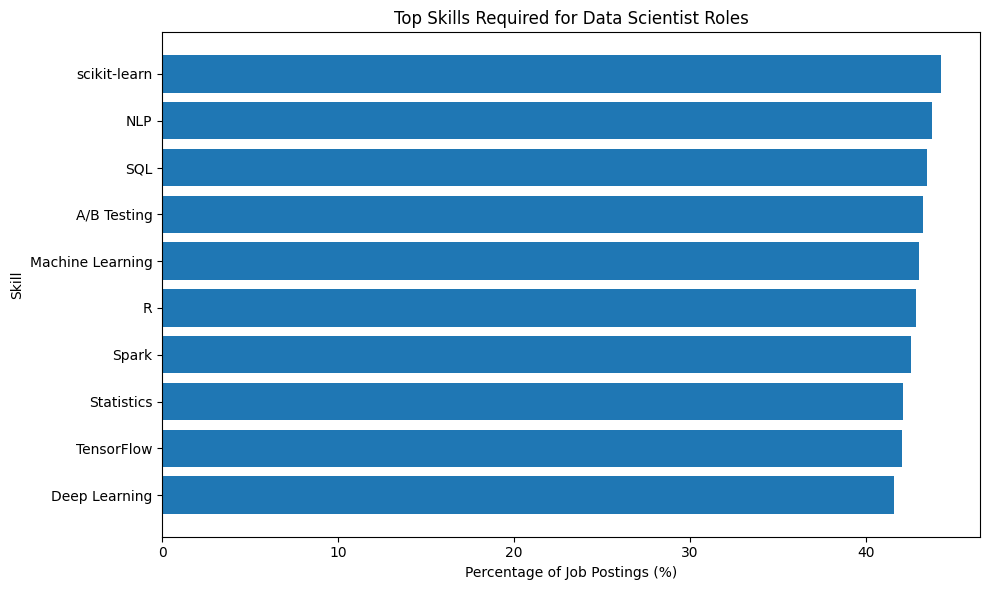

In [81]:
ds_demand = skill_demand_by_role(df, 'Data Scientist', 10)

plt.figure(figsize=(10, 6))

plt.barh(
    ds_demand['Skill'][::-1],
    ds_demand['Demand_Percentage'][::-1]
)

plt.xlabel('Percentage of Job Postings (%)')
plt.ylabel('Skill')
plt.title('Top Skills Required for Data Scientist Roles')

plt.tight_layout()
plt.show()

In [82]:
df['skill_count'].describe()

count    15000.000000
mean         5.824533
std          1.997234
min          2.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: skill_count, dtype: float64

In [83]:
da_skills.head(15)

required_skills
A/B Testing         897
Statistics          894
Tableau             890
Excel               887
dbt                 884
Power BI            883
Google Analytics    880
Looker              880
Python              877
SQL                 876
Name: count, dtype: int64

In [84]:
skill_demand_by_role(df, 'Data Scientist', 15)

,Skill,Job_Postings,Demand_Percentage
0,scikit-learn,657,44.27
1,NLP,649,43.73
2,SQL,645,43.46
3,A/B Testing,642,43.26
4,Machine Learning,638,42.99
5,R,636,42.86
6,Spark,632,42.59
7,Statistics,625,42.12
8,TensorFlow,624,42.05
9,Deep Learning,617,41.58


### STEP 25 — Create the complete Career Skill Analysis

In [85]:
def get_role_skill_profile(data, role):
    
    role_jobs = data[data['title'] == role]
    total_jobs = len(role_jobs)
    
    skills = (
        role_jobs['required_skills']
        .dropna()
        .str.split('|')
        .explode()
        .str.strip()
    )
    
    skill_counts = skills.value_counts()
    
    result = pd.DataFrame({
        'Skill': skill_counts.index,
        'Job_Postings': skill_counts.values
    })
    
    result['Demand_Percentage'] = (
        result['Job_Postings'] / total_jobs * 100
    ).round(2)
    
    result['Career'] = role
    
    return result

In [86]:
ds_profile = get_role_skill_profile(df, 'Data Scientist')

ds_profile.head(15)

,Skill,Job_Postings,Demand_Percentage,Career
0,scikit-learn,657,44.27,Data Scientist
1,NLP,649,43.73,Data Scientist
2,SQL,645,43.46,Data Scientist
3,A/B Testing,642,43.26,Data Scientist
4,Machine Learning,638,42.99,Data Scientist
5,R,636,42.86,Data Scientist
6,Spark,632,42.59,Data Scientist
7,Statistics,625,42.12,Data Scientist
8,TensorFlow,624,42.05,Data Scientist
9,Deep Learning,617,41.58,Data Scientist


In [87]:
da_profile = get_role_skill_profile(df, 'Data Analyst')

da_profile.head(15)

,Skill,Job_Postings,Demand_Percentage,Career
0,A/B Testing,897,59.01,Data Analyst
1,Statistics,894,58.82,Data Analyst
2,Tableau,890,58.55,Data Analyst
3,Excel,887,58.36,Data Analyst
4,dbt,884,58.16,Data Analyst
5,Power BI,883,58.09,Data Analyst
6,Google Analytics,880,57.89,Data Analyst
7,Looker,880,57.89,Data Analyst
8,Python,877,57.70,Data Analyst
9,SQL,876,57.63,Data Analyst


### STEP 26 — Generate profiles for ALL careers

In [88]:
career_profiles = []

for role in df['title'].unique():
    
    profile = get_role_skill_profile(df, role)
    career_profiles.append(profile)

career_skill_profiles = pd.concat(
    career_profiles,
    ignore_index=True
)

career_skill_profiles.head()

,Skill,Job_Postings,Demand_Percentage,Career
0,scikit-learn,657,44.27,Data Scientist
1,NLP,649,43.73,Data Scientist
2,SQL,645,43.46,Data Scientist
3,A/B Testing,642,43.26,Data Scientist
4,Machine Learning,638,42.99,Data Scientist


In [89]:
print("Total career-skill records:",
      len(career_skill_profiles))

Total career-skill records: 117


In [90]:
print("Number of careers:",
      career_skill_profiles['Career'].nunique())

print("Number of skills:",
      career_skill_profiles['Skill'].nunique())

Number of careers: 10
Number of skills: 69


### STEP 27 — Save this important dataset

In [93]:
career_skill_profiles.to_csv(
    "data/career_skill_profiles.csv",
    index=False
)

print("Career skill profiles saved successfully.")

Career skill profiles saved successfully.


### STEP 28 — Compare career profiles

In [94]:
top_skills_by_career = (
    career_skill_profiles
    .sort_values(
        ['Career', 'Demand_Percentage'],
        ascending=[True, False]
    )
    .groupby('Career')
    .head(5)
)

top_skills_by_career

,Skill,Job_Postings,Demand_Percentage,Career
46,Java,733,50.10,Backend Engineer
47,gRPC,728,49.76,Backend Engineer
48,Python,727,49.69,Backend Engineer
49,Redis,722,49.35,Backend Engineer
50,Kafka,722,49.35,Backend Engineer
107,A/B Testing,897,59.01,Data Analyst
108,Statistics,894,58.82,Data Analyst
109,Tableau,890,58.55,Data Analyst
110,Excel,887,58.36,Data Analyst
111,dbt,884,58.16,Data Analyst


### STEP 29 — Create our first comparison visualization

In [95]:
selected_roles = [
    'Data Analyst',
    'Data Scientist',
    'Data Engineer',
    'ML Engineer'
]

comparison_data = career_skill_profiles[
    career_skill_profiles['Career'].isin(selected_roles)
]

top_comparison = (
    comparison_data
    .sort_values('Demand_Percentage', ascending=False)
    .groupby('Career')
    .head(5)
)

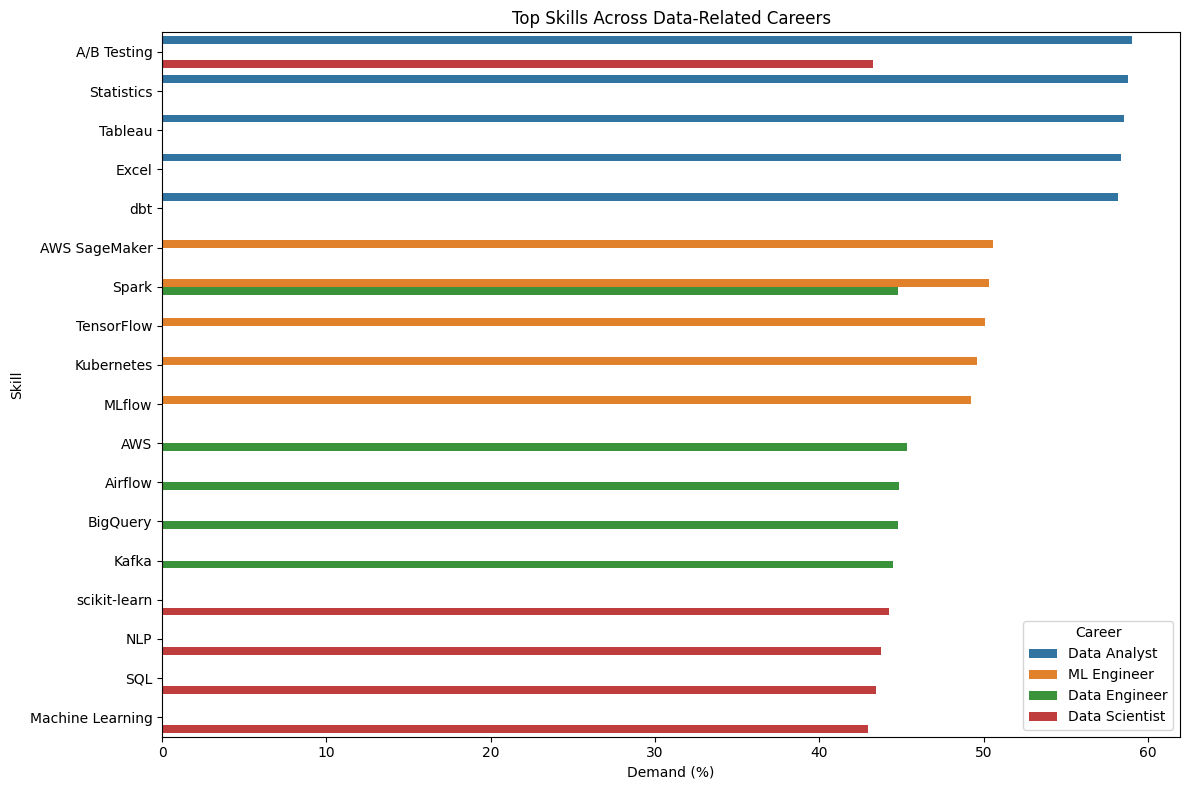

In [96]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_comparison,
    x='Demand_Percentage',
    y='Skill',
    hue='Career'
)

plt.title('Top Skills Across Data-Related Careers')
plt.xlabel('Demand (%)')
plt.ylabel('Skill')

plt.tight_layout()
plt.show()

### Find Career-Specific Skills

In [97]:
skill_career_counts = (
    career_skill_profiles
    .groupby('Skill')['Career']
    .nunique()
    .sort_values()
)

skill_career_counts.head(20)

Skill
Adobe XD            1
AWS SageMaker       1
Ansible             1
Agile               1
Databricks          1
Data Analysis       1
C++                 1
BigQuery            1
Design Systems      1
HTML/CSS            1
Git                 1
Google Analytics    1
GCP                 1
Feature Stores      1
Experimentation     1
Excel               1
Jupyter             1
Jenkins             1
JIRA                1
JavaScript          1
Name: Career, dtype: int64

### Find skills unique to one career

In [98]:
unique_skills = career_skill_profiles[
    career_skill_profiles['Skill'].map(skill_career_counts) == 1
]

unique_skills.sort_values('Career')

,Skill,Job_Postings,Demand_Percentage,Career
47,gRPC,728,49.76,Backend Engineer
114,Looker,880,57.89,Data Analyst
112,Power BI,883,58.09,Data Analyst
110,Excel,887,58.36,Data Analyst
113,Google Analytics,880,57.89,Data Analyst
16,BigQuery,670,44.79,Data Engineer
22,Redshift,649,43.38,Data Engineer
24,Snowflake,646,43.18,Data Engineer
0,scikit-learn,657,44.27,Data Scientist
1,NLP,649,43.73,Data Scientist


In [99]:
common_skills = career_skill_profiles[
    career_skill_profiles['Skill'].map(skill_career_counts) >= 5
]

common_skills.sort_values(
    ['Skill', 'Demand_Percentage'],
    ascending=[True, False]
)

,Skill,Job_Postings,Demand_Percentage,Career
38,Python,963,66.46,Research Scientist
115,Python,877,57.70,Data Analyst
48,Python,727,49.69,Backend Engineer
91,Python,743,49.08,ML Engineer
62,Python,662,45.59,DevOps Engineer
21,Python,655,43.78,Data Engineer
71,Python,641,41.30,Software Engineer
10,Python,605,40.77,Data Scientist
35,SQL,880,57.89,Product Manager
116,SQL,876,57.63,Data Analyst


In [100]:
career_skill_matrix = career_skill_profiles.pivot_table(
    index='Career',
    columns='Skill',
    values='Demand_Percentage',
    fill_value=0
)

career_skill_matrix

Skill,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,CI/CD,Data Analysis,Databricks,Deep Learning,Design Systems,Docker,Excel,Experimentation,Feature Stores,Figma,GCP,Git,Go,Google Analytics,Grafana,HTML/CSS,JIRA,Java,JavaScript,Jenkins,Jupyter,Kafka,Kubernetes,LaTeX,Linux,Looker,MLflow,Machine Learning,NLP,PostgreSQL,Power BI,Product Strategy,Prometheus,Prototyping,Publication Record,PyTorch,Python,R,REST APIs,Redis,Redshift,Roadmapping,Rust,SQL,Sketch,Snowflake,Spark,Stakeholder Management,Statistics,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
Career,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Backend Engineer,0.00,48.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,46.96,0.00,0.00,0.00,0.00,0.00,0.00,47.37,0.00,0.00,0.00,0.00,50.10,0.00,0.00,0.00,49.35,46.96,0.00,0.00,0.00,0.00,0.00,0.00,48.26,0.00,0.00,0.00,0.00,0.00,0.00,49.69,0.00,46.34,49.35,0.00,0.00,0.0,49.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,49.76,0.00
Data Analyst,59.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,58.36,0.00,0.00,0.00,0.00,0.00,0.00,57.89,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,57.89,0.00,0.00,0.00,0.00,58.09,0.00,0.00,0.00,0.00,0.00,57.70,0.00,0.00,0.00,0.00,0.00,0.0,57.63,0.00,0.00,0.00,0.00,58.82,58.55,0.00,0.00,0.00,0.00,0.00,0.00,58.16,0.00,0.00
Data Engineer,0.00,45.32,0.00,0.00,0.00,44.85,0.00,42.85,44.79,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.52,0.00,0.00,0.00,0.00,0.00,0.00,0.00,43.25,0.00,0.00,0.00,0.00,0.00,0.00,43.78,0.00,0.00,0.00,43.38,0.00,0.0,44.32,0.00,43.18,44.79,0.00,0.00,0.00,0.00,42.71,0.00,0.00,0.00,0.00,44.32,0.00,0.00
Data Scientist,43.26,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,41.58,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,38.81,0.00,0.00,0.00,0.00,0.00,0.00,42.99,43.73,0.00,0.00,0.00,0.00,0.00,0.00,40.70,40.77,42.86,0.00,0.00,0.00,0.00,0.0,43.46,0.00,0.00,42.59,0.00,42.12,39.89,42.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.27
DevOps Engineer,0.00,47.59,0.00,0.00,0.00,0.00,46.07,42.98,0.00,0.00,45.25,0.00,0.00,0.00,0.00,45.11,0.00,0.00,0.00,0.00,45.45,0.00,0.00,0.00,45.52,0.00,0.00,0.00,0.00,48.07,0.00,0.00,42.91,0.00,45.52,0.00,0.00,0.00,0.00,0.00,0.00,0.00,46.49,0.00,0.00,0.00,45.59,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ML Engineer,0.00,0.00,50.59,0.00,0.00,48.35,0.00,0.00,0.00,0.00,48.68,0.00,47.95,0.00,0.00,48.41,0.00,0.00,48.22,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,49.60,0.00,0.00,0.00,49.21,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,48.41,49.08,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,50.33,0.00,0.00,0.00,50.07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Product Manager,58.75,0.00,0.00,0.00,59.01,0.00,0.00,0.00,0.00,0.00,0.00,60.46,0.00,0.00,0.00,0.00,0.00,0.00,0.00,59.74,0.00,0.00,0.00,0.00,0.00,0.00,58.82,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,58.95,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,59.74,0.0,57.89,0.00,0.00,0.00,57.37,0.00,0.00,0.00,0.00,0.00,0.00,59.08,0.00,0.00,0.00,0.00
Research Scientist,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,64.39,0.00,0.00,0.00,65.15,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,65.08,0.00,0.00,0.00,64.60,0.00,0.00,0.00,0.00,0.00,0.00,66.39,66.74,66.46,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,64.53,0.00,65.42,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Software Engineer,0.00,38.21,0.00,0.00,0.00,0.00,0.00,0.00,0.00,37.76,0.00,0.00,0.00,0.00,0.00,38.66,0.00,0.00,0.00,0.00,0.00,39.63,38.92,0.00,0.00,0.00,0.00,37.82,37.82,0.00,0.00,0.00,39.43,0.00,0.00,0.00,0.00,0.00,0.00,35.95,0.00,0.00,0.00,0.00,0.00,0.00,41.30,0.00,39.37,38.27,0.00,0.00,36.6,37.44,0.00,0.00

In [101]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(career_skill_matrix)

career_similarity = pd.DataFrame(
    similarity_matrix,
    index=career_skill_matrix.index,
    columns=career_skill_matrix.index
)

career_similarity.round(2)

Career,Backend Engineer,Data Analyst,Data Engineer,Data Scientist,DevOps Engineer,ML Engineer,Product Manager,Research Scientist,Software Engineer,UX Designer
Career,,,,,,,,,,
Backend Engineer,1.00,0.18,0.41,0.16,0.32,0.25,0.09,0.10,0.74,0.00
Data Analyst,0.18,1.00,0.26,0.42,0.09,0.09,0.20,0.21,0.17,0.00
Data Engineer,0.41,0.26,1.00,0.22,0.30,0.24,0.09,0.09,0.29,0.00
Data Scientist,0.16,0.42,0.22,1.00,0.07,0.31,0.17,0.53,0.14,0.00
DevOps Engineer,0.32,0.09,0.30,0.07,1.00,0.31,0.00,0.09,0.29,0.00
ML Engineer,0.25,0.09,0.24,0.31,0.31,1.00,0.00,0.29,0.23,0.00
Product Manager,0.09,0.20,0.09,0.17,0.00,0.00,1.00,0.00,0.08,0.21
Research Scientist,0.10,0.21,0.09,0.53,0.09,0.29,0.00,1.00,0.09,0.00
Software Engineer,0.74,0.17,0.29,0.14,0.29,0.23,0.08,0.09,1.00,0.00


In [102]:
df['salary_avg'] = (
    df['salary_min'] + df['salary_max']
) / 2

df[['salary_min', 'salary_max', 'salary_avg']].head()

,salary_min,salary_max,salary_avg
0,138000,164000,151000.0
1,85000,103000,94000.0
2,63000,77000,70000.0
3,61000,71000,66000.0
4,208000,245000,226500.0


In [103]:
salary_by_career = (
    df.groupby('title')['salary_avg']
    .agg(['mean', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

salary_by_career

,mean,min,max
title,,,
ML Engineer,185034.015852,55000.0,511000.0
Research Scientist,184914.423741,55000.0,499500.0
Data Scientist,182740.902965,55500.0,507000.0
DevOps Engineer,161172.176309,50500.0,450000.0
Backend Engineer,158616.541353,45500.0,423500.0
Product Manager,157966.447368,47000.0,458000.0
Data Analyst,156828.947368,46000.0,479500.0
Software Engineer,156636.597938,49500.0,442500.0
Data Engineer,154444.518717,49500.0,449000.0


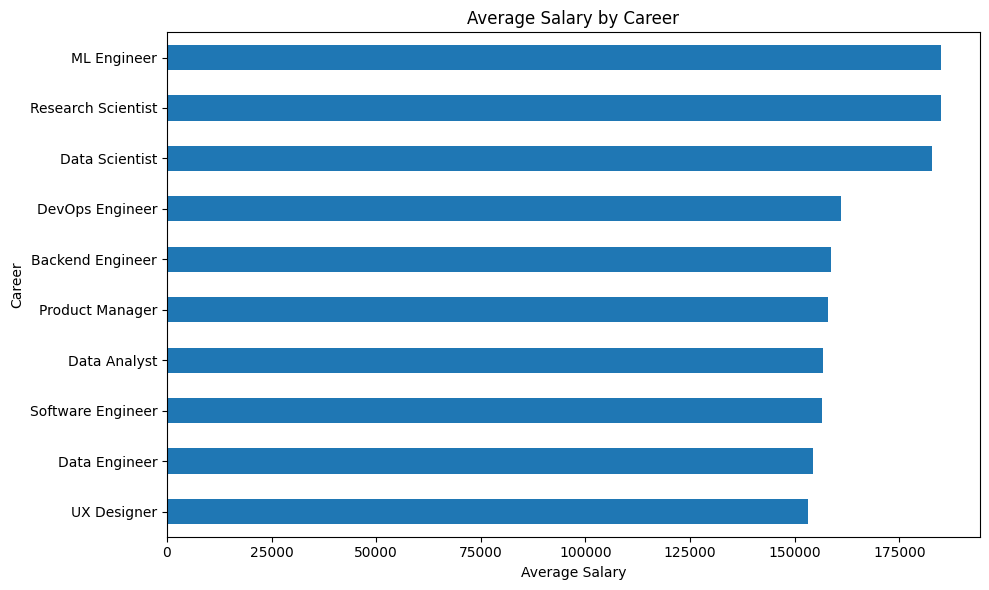

In [104]:
plt.figure(figsize=(10, 6))

salary_by_career['mean'].sort_values().plot(kind='barh')

plt.title('Average Salary by Career')
plt.xlabel('Average Salary')
plt.ylabel('Career')

plt.tight_layout()
plt.show()

In [105]:
experience_salary = (
    df.groupby('experience_level')['salary_avg']
    .mean()
    .sort_values()
)

experience_salary

experience_level
entry        89092.031610
mid         132327.089995
senior      184047.909817
lead        228210.162214
director    295235.174655
Name: salary_avg, dtype: float64

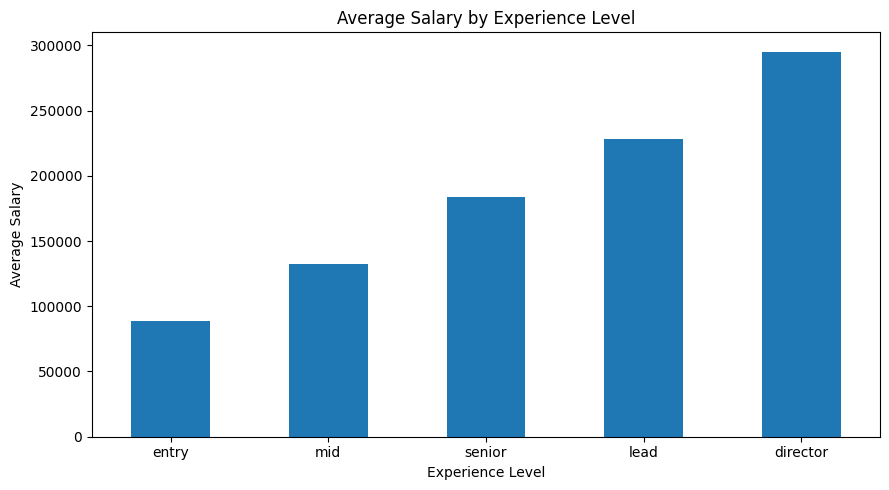

In [106]:
plt.figure(figsize=(9, 5))

experience_salary.plot(kind='bar')

plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Job Market by Industry

In [107]:
industry_counts = df['industry'].value_counts()

industry_counts

industry
finance          1924
education        1913
government       1894
media            1873
manufacturing    1867
retail           1857
tech             1842
healthcare       1830
Name: count, dtype: int64

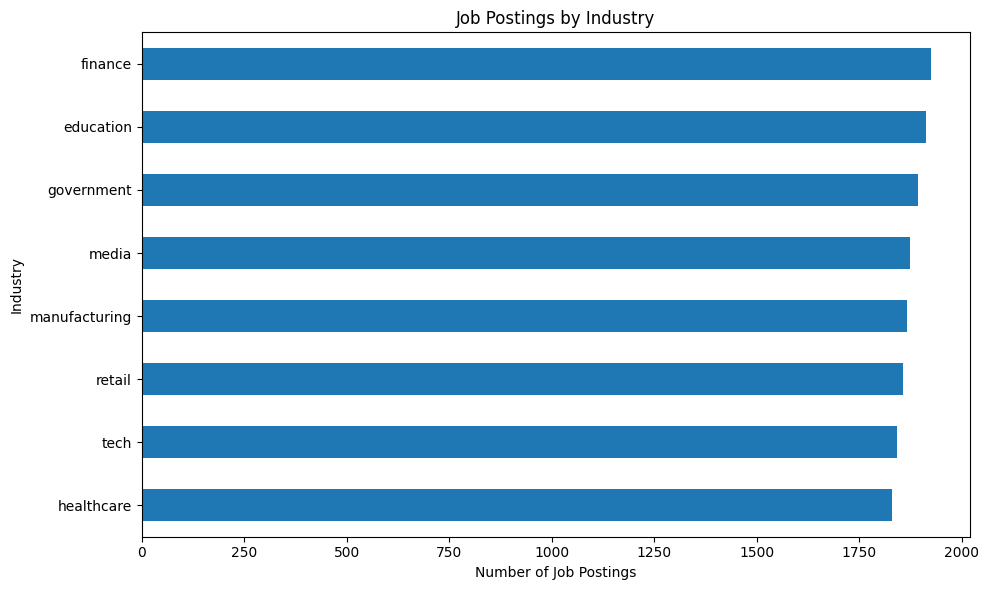

In [108]:
plt.figure(figsize=(10, 6))

industry_counts.sort_values().plot(kind='barh')

plt.title('Job Postings by Industry')
plt.xlabel('Number of Job Postings')
plt.ylabel('Industry')

plt.tight_layout()
plt.show()

### Career by Industry

In [109]:
career_industry = pd.crosstab(
    df['title'],
    df['industry']
)

career_industry

industry,education,finance,government,healthcare,manufacturing,media,retail,tech
title,,,,,,,,
Backend Engineer,191,179,187,172,172,189,185,188
Data Analyst,208,204,218,198,163,171,180,178
Data Engineer,208,150,179,191,192,187,200,189
Data Scientist,189,191,176,186,184,200,179,179
DevOps Engineer,163,206,177,182,196,187,179,162
ML Engineer,196,202,181,167,195,188,192,193
Product Manager,184,198,231,163,196,183,179,186
Research Scientist,173,187,175,173,194,178,181,188
Software Engineer,208,187,184,188,197,203,196,189


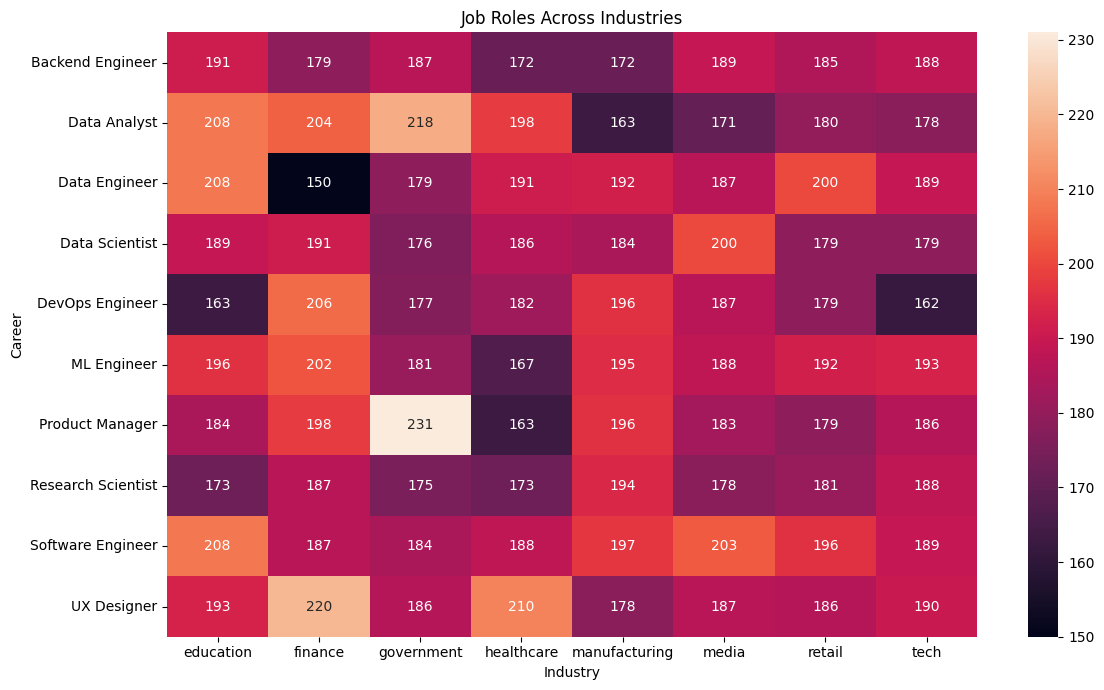

In [110]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    career_industry,
    annot=True,
    fmt='d'
)

plt.title('Job Roles Across Industries')
plt.xlabel('Industry')
plt.ylabel('Career')

plt.tight_layout()
plt.show()

### Remote Work Analysis

In [111]:
remote_salary = (
    df.groupby('remote_type')['salary_avg']
    .mean()
    .sort_values(ascending=False)
)

remote_salary

remote_type
remote    176100.734639
hybrid    160555.148284
onsite    159929.649356
Name: salary_avg, dtype: float64

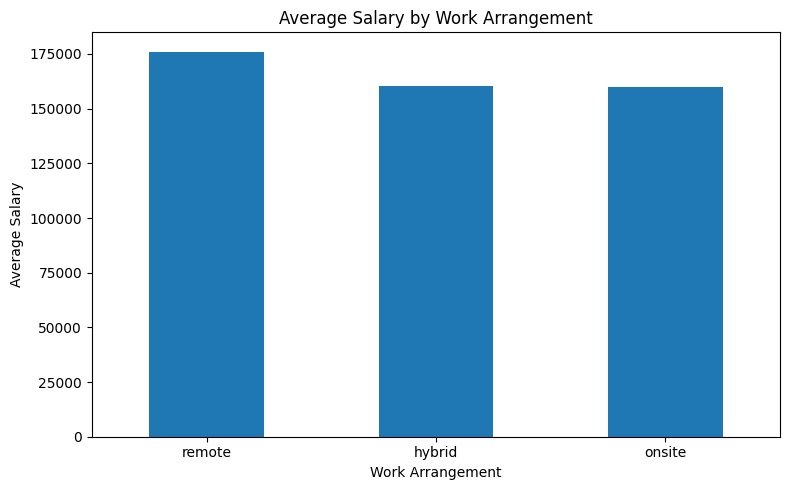

In [112]:
plt.figure(figsize=(8, 5))

remote_salary.plot(kind='bar')

plt.title('Average Salary by Work Arrangement')
plt.xlabel('Work Arrangement')
plt.ylabel('Average Salary')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Job Market Trend

In [113]:
df['year'] = df['posted_date'].dt.year

In [114]:
yearly_jobs = df['year'].value_counts().sort_index()

yearly_jobs

year
2023    4968
2024    5089
2025    4943
Name: count, dtype: int64

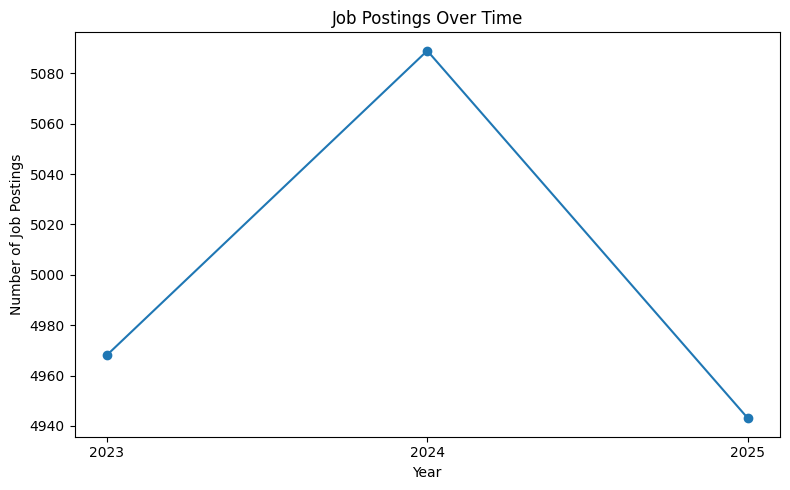

In [115]:
plt.figure(figsize=(8, 5))

yearly_jobs.plot(kind='line', marker='o')

plt.title('Job Postings Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Job Postings')

plt.xticks(yearly_jobs.index)
plt.tight_layout()
plt.show()

### Skill Demand Over Time

In [116]:
python_demand = (
    df.assign(
        has_python=df['required_skills'].str.contains(
            'Python',
            case=False,
            na=False
        )
    )
    .groupby('year')['has_python']
    .mean() * 100
)

python_demand

year
2023    38.607085
2024    40.204362
2025    38.620271
Name: has_python, dtype: float64

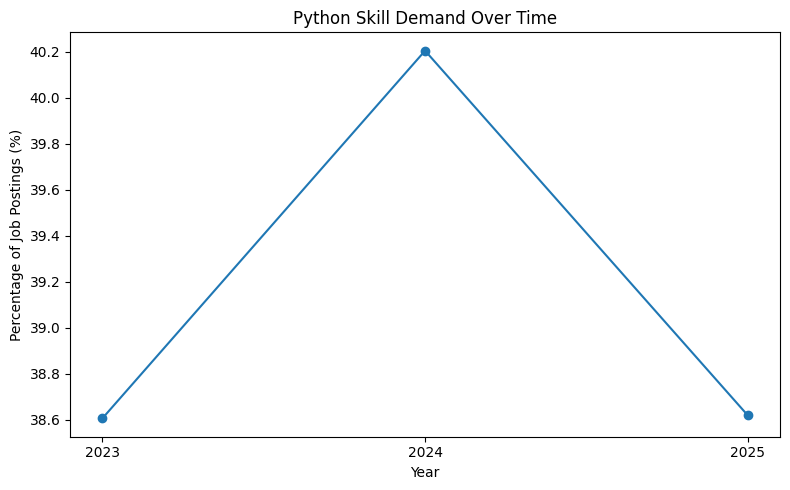

In [117]:
plt.figure(figsize=(8, 5))

python_demand.plot(
    kind='line',
    marker='o'
)

plt.title('Python Skill Demand Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage of Job Postings (%)')

plt.xticks(python_demand.index)
plt.tight_layout()
plt.show()

In [118]:
# Correlation analysis of numerical variables

numeric_columns = [
    'salary_min',
    'salary_max',
    'applications',
    'days_to_fill',
    'salary_avg'
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,salary_min,salary_max,applications,days_to_fill,salary_avg
salary_min,1.000000,0.993026,0.259001,0.683837,0.997830
salary_max,0.993026,1.000000,0.258167,0.678696,0.998633
applications,0.259001,0.258167,1.000000,-0.002143,0.258982
days_to_fill,0.683837,0.678696,-0.002143,1.000000,0.682145
salary_avg,0.997830,0.998633,0.258982,0.682145,1.000000


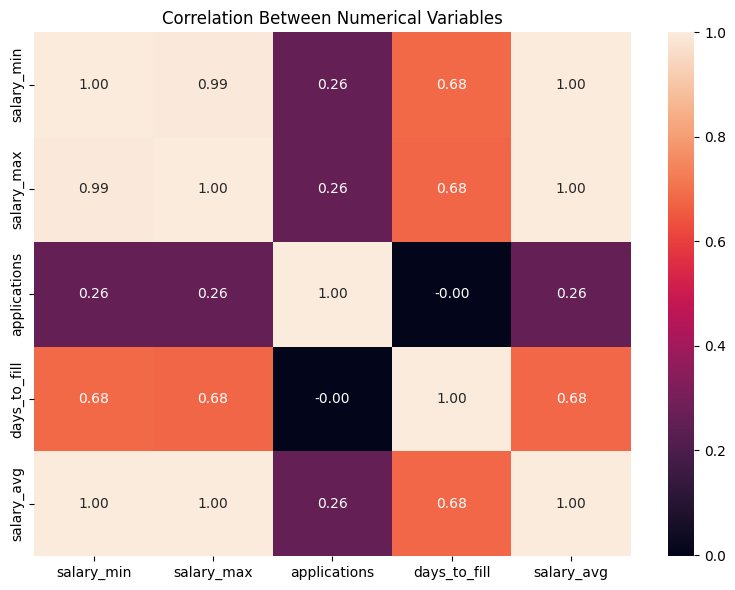

In [119]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Numerical Variables')
plt.tight_layout()
plt.show()

In [120]:
# Outlier analysis using the IQR method

outlier_columns = [
    'salary_avg',
    'applications',
    'days_to_fill'
]

outlier_summary = []

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        'Variable': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,salary_avg,111500.0,205000.0,93500.0,-28750.0,345250.0,303
1,applications,45.0,143.0,98.0,-102.0,290.0,0
2,days_to_fill,34.0,72.0,38.0,-23.0,129.0,525


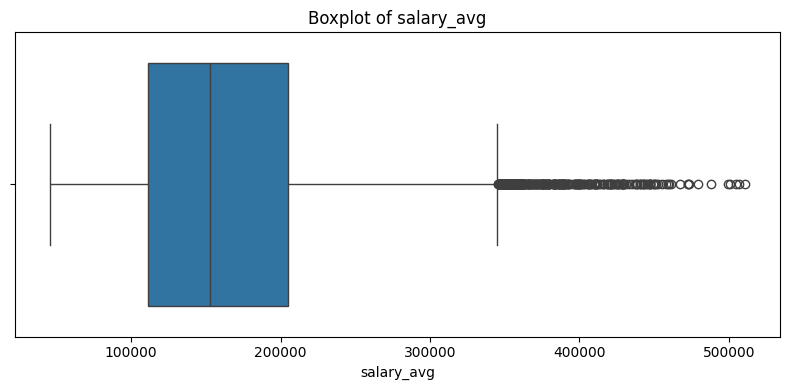

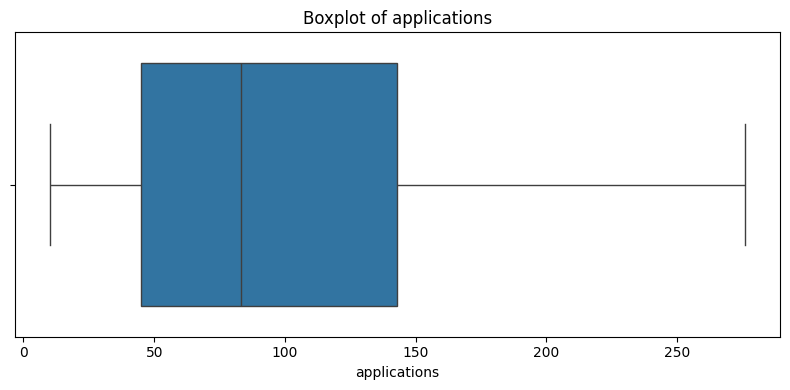

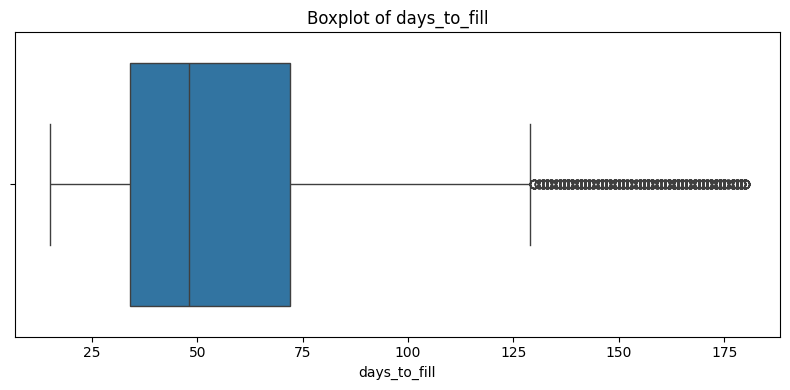

In [121]:
# Boxplots for numerical variables

for column in outlier_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

## 19. Key Findings from Exploratory Data Analysis

The exploratory data analysis of 15,000 job postings produced several important findings about the job market.

### Job Market Structure
- The dataset contains 15,000 unique job postings covering 10 different career roles and 8 industries.
- Job postings are relatively balanced across the different career categories and industries.
- Finance has the highest number of job postings among the industries, with 1,924 postings.

### Experience and Education
- Mid-level positions represent the largest experience category, followed by senior and entry-level positions.
- Bachelor's degree requirements are the most common educational requirement, followed by master's and PhD qualifications.

### Salary Analysis
- ML Engineer has the highest average salary among the analyzed career roles.
- Salary increases substantially with experience level.
- Director-level positions have the highest average salary, while entry-level positions have the lowest.
- Remote positions have a higher average salary than hybrid and onsite positions.

### Skill Demand
- Python is the most frequently requested technical skill in the dataset.
- Other highly demanded skills include SQL, Docker, Kubernetes, AWS, Statistics, A/B Testing, TensorFlow, and PyTorch.
- Different careers demonstrate different skill requirements, highlighting the importance of career-specific skill analysis.

### Industry and Career Relationships
- The career-industry analysis shows that the identified job roles are distributed across multiple industries.
- This indicates that many technical and analytical careers can provide opportunities across different sectors.

### Job Market Trends
- The number of job postings remains relatively stable across 2023, 2024, and 2025.
- Python demand remained relatively stable, ranging from approximately 38.6% to 40.2% of job postings during the three-year period.

### Correlation Analysis
- Salary variables have very strong positive correlations with each other.
- Salary and days to fill show a moderate-to-strong positive relationship.
- Applications have only a weak relationship with salary.
- Applications and days to fill show almost no linear correlation.

### Outlier Analysis
- Outlier analysis identified some unusually high salary values and longer hiring durations.
- Application counts did not contain statistical outliers based on the IQR method.
- The identified salary and hiring-duration outliers were retained because they may represent genuine job-market observations.

### Overall Conclusion
The exploratory analysis demonstrates that job opportunities, salaries, experience requirements, and skill demands vary considerably across career roles. These findings provide a strong foundation for the next stage of the project, which will focus on detailed skill analysis, NLP-based processing of job descriptions, and the development of a career recommendation and skill-gap analysis system.

In [124]:
# Save the processed dataset

df.to_csv("data/job_postings_processed.csv", index=False)

print("Processed dataset saved successfully.")
print("Shape:", df.shape)

Processed dataset saved successfully.
Shape: (15000, 19)


In [127]:
career_skill_profiles.to_csv(
    "data/career_skill_profiles.csv",
    index=False
)

print("Career skill profile saved successfully.")
print("Shape:", career_skill_profiles.shape)

Career skill profile saved successfully.
Shape: (117, 4)
